<a href="https://colab.research.google.com/github/camilavazquezz/colab/blob/main/Part%203%20customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [14]:
# Data source: Kaggle - Customer Personality Analysis
# https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

path = kagglehub.dataset_download(
    "imakash3011/customer-personality-analysis"
)

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Dataset downloaded to: /kaggle/input/customer-personality-analysis
Files: ['marketing_campaign.csv']


In [15]:
csv_path = os.path.join(path, "marketing_campaign.csv")

df = pd.read_csv(csv_path, sep="\t")

print("Number of customers:", len(df))
print("\nColumns:")
print(df.columns.tolist())

df.head()

Number of customers: 2240

Columns:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [16]:
# Create features similar to the starter code

# Calculate total customer spending
df['annual_spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

# Calculate total purchase frequency
df['purchase_frequency'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

# Calculate customer age
df['age'] = 2014 - df['Year_Birth']

# Select the same numerical features used in the starter code
features = ['annual_spending', 'purchase_frequency', 'age']

customer_data = df[features].copy()

customer_data.head(10)

,annual_spending,purchase_frequency,age
0,1617,22,57
1,27,4,60
2,776,20,49
3,53,6,30
4,422,14,33
5,716,20,47
6,590,17,43
7,169,8,29
8,46,5,40
9,49,1,64


In [17]:
# Check for missing values
print("Missing values:")
print(customer_data.isnull().sum())

# Check age range
print("\nMinimum age:", customer_data['age'].min())
print("Maximum age:", customer_data['age'].max())

Missing values:
annual_spending       0
purchase_frequency    0
age                   0
dtype: int64

Minimum age: 18
Maximum age: 121


In [18]:
# Remove unrealistic age outliers
customer_data = customer_data[
    (customer_data['age'] >= 18) &
    (customer_data['age'] <= 100)
].copy()

print("Customers after cleaning:", len(customer_data))
print("Minimum age:", customer_data['age'].min())
print("Maximum age:", customer_data['age'].max())

Customers after cleaning: 2237
Minimum age: 18
Maximum age: 74


In [19]:
# Scale the numerical features
features = ['annual_spending', 'purchase_frequency', 'age']

X = customer_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")
print("Number of customers:", len(X_scaled))

Features scaled successfully!
Number of customers: 2237


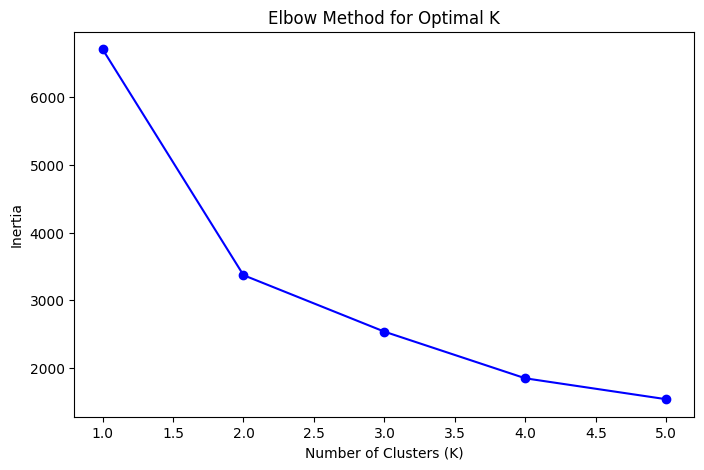

In [20]:
# Determine the optimal number of clusters using the elbow method
inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

# Save the graph as required by the starter code
plt.savefig('elbow_plot.png')

# Display the graph in Colab
plt.show()

In [21]:
# Apply K-Means with K=3
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

customer_data['cluster'] = kmeans.fit_predict(X_scaled)

# Display the first 10 customers with their assigned cluster
customer_data.head(10)

,annual_spending,purchase_frequency,age,cluster
0,1617,22,57,1
1,27,4,60,0
2,776,20,49,1
3,53,6,30,2
4,422,14,33,2
5,716,20,47,1
6,590,17,43,1
7,169,8,29,2
8,46,5,40,2
9,49,1,64,0


In [22]:
# Analyze the characteristics of each cluster
cluster_summary = customer_data.groupby('cluster')[features].mean().round(2)

print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                 290.79                9.75  57.47
1                1244.30               19.93  46.07
2                 137.59                6.65  37.23


In [23]:
# Suggest targeted marketing strategies for each customer segment
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")

    if cluster == 0:
        print("Older, moderate-engagement customers: Offer personalized promotions and loyalty incentives to encourage more frequent purchases.")

    elif cluster == 1:
        print("High-spending, frequent customers: Offer exclusive promotions, VIP rewards, and loyalty benefits.")

    elif cluster == 2:
        print("Younger, low-engagement customers: Use targeted digital promotions and introductory discounts to increase engagement.")


Cluster 0 Strategy:
Older, moderate-engagement customers: Offer personalized promotions and loyalty incentives to encourage more frequent purchases.

Cluster 1 Strategy:
High-spending, frequent customers: Offer exclusive promotions, VIP rewards, and loyalty benefits.

Cluster 2 Strategy:
Younger, low-engagement customers: Use targeted digital promotions and introductory discounts to increase engagement.


In [24]:
# Save customer cluster assignments to a CSV file
customer_data.to_csv('customer_segments.csv', index=False)

print("Customer segments saved successfully!")

Customer segments saved successfully!
